<a href="https://colab.research.google.com/github/Madhankumar-17/Day8/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression for TrafficIQ — Smart Traffic & Congestion Predictor

This section will demonstrate how to build a logistic regression model to classify spam messages using the 'smart_traffic_management_dataset.csv' dataset.

Saving smart_traffic_management_dataset.csv to smart_traffic_management_dataset.csv
          timestamp  location_id  traffic_volume  avg_vehicle_speed  \
0  01-01-2024 00:00            4             504          53.124162   
1  01-01-2024 00:01            5             209          44.947850   
2  01-01-2024 00:02            3             572          63.179229   
3  01-01-2024 00:03            5             699          42.269697   
4  01-01-2024 00:04            5             639          72.185791   

   vehicle_count_cars  vehicle_count_trucks  vehicle_count_bikes  \
0                 142                    24                   44   
1                 862                    50                   23   
2                 317                    12                   10   
3                 709                    43                   21   
4                 594                    34                   14   

  weather_condition  temperature   humidity  accident_reported signal_status  
0

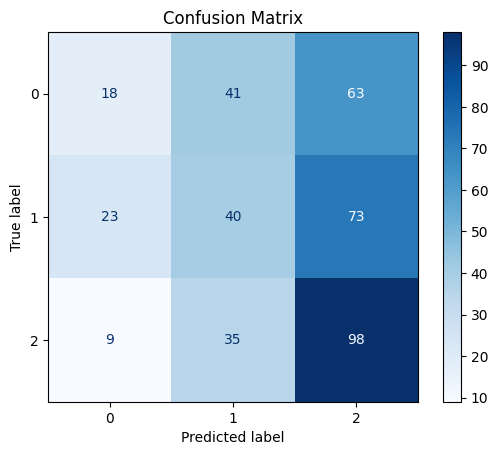


Feature Importance
                Feature  Coefficient  Absolute
4  vehicle_count_trucks     0.055136  0.055136
9     accident_reported     0.051337  0.051337
8              humidity    -0.051330  0.051330
3    vehicle_count_cars    -0.046473  0.046473
1        traffic_volume     0.031317  0.031317
7           temperature    -0.025930  0.025930
0           location_id    -0.024985  0.024985
5   vehicle_count_bikes    -0.024211  0.024211
2     avg_vehicle_speed     0.023234  0.023234
6     weather_condition     0.022861  0.022861


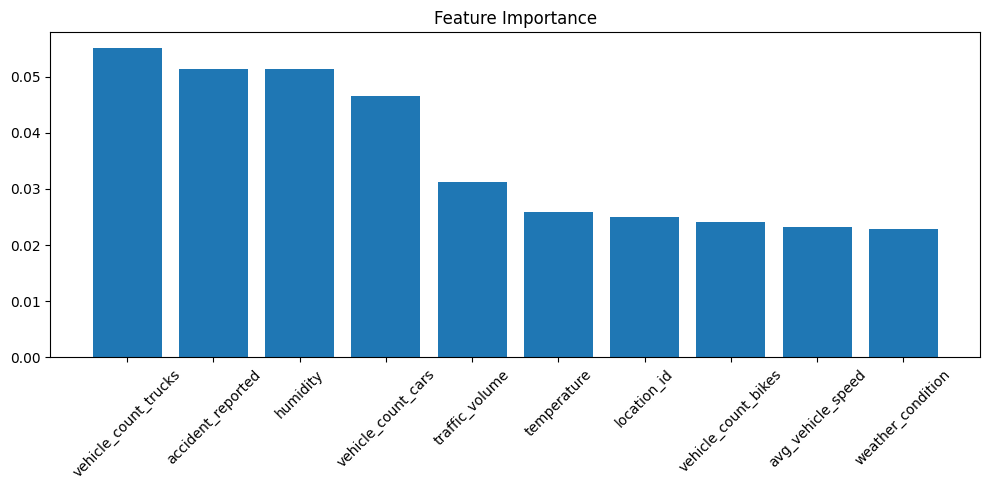


Model Saved Successfully!


In [ ]:
# ============================================================
# Smart Traffic Management System
# Logistic Regression + RandomizedSearchCV
# Google Colab
# ============================================================

# Install libraries (if needed)
!pip -q install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from scipy.stats import uniform

# ============================================================
# Upload Dataset
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())

# ============================================================
# Drop Timestamp
# ============================================================

df.drop("timestamp", axis=1, inplace=True)

# ============================================================
# Encode Categorical Columns
# ============================================================

encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        encoder = LabelEncoder()
        df[column] = encoder.fit_transform(df[column])
        encoders[column] = encoder

# ============================================================
# Features and Target
# ============================================================

X = df.drop("signal_status", axis=1)

y = df["signal_status"]

# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Logistic Regression Model
# ============================================================

model = LogisticRegression(max_iter=1000)

# ============================================================
# Hyperparameter Distribution
# ============================================================

param_dist = {

    "C": uniform(0.01,10),

    "solver":[
        "lbfgs",
        "newton-cg",
        "saga"
    ],

    "penalty":[
        "l2"
    ]
}

# ============================================================
# RandomizedSearchCV
# ============================================================

random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

# ============================================================
# Train Model
# ============================================================

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\nBest Parameters")
print(random_search.best_params_)

print("\nBest CV Accuracy")
print(random_search.best_score_)

# ============================================================
# Prediction
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy")

print(f"{accuracy*100:.2f}%")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": best_model.coef_[0]

})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Absolute"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "traffic_logistic_randomsearch.pkl")
joblib.dump(scaler, "traffic_scaler.pkl")

print("\nModel Saved Successfully!")

### Data Preprocessing

1.  **Rename columns**: Rename `v1` to `label` and `v2` to `text` for better readability.
2.  **Handle missing values**: Check and remove any rows with missing data.
3.  **Encode labels**: Convert categorical labels ('ham', 'spam') into numerical format (0, 1).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Note: TF-IDF Vectorizer was removed as it is for text data,
# not for numerical sensor data.

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Training set size: 1200
Testing set size: 800

Shape of X_train: (1200, 11)
Shape of X_test: (800, 11)


### 1. Feature Scaling
Since we have a new split, we must fit the scaler on `X_train` and transform both `X_train` and `X_test` to ensure the model interprets the sensor values correctly.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize and fit scaler on the new training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


### 2. Train Logistic Regression Model
We will initialize the model using the best hyperparameters found during the previous search (`C=3.755`, `solver='lbfgs'`).

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model with optimized hyperparameters
final_model = LogisticRegression(C=3.7554, solver='lbfgs', max_iter=1000)

# Fit the model
final_model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


### 3. Model Evaluation
Let's check how the model performs on the 40% test set.

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.15      0.21       122
           1       0.34      0.29      0.32       136
           2       0.42      0.69      0.52       142

    accuracy                           0.39       400
   macro avg       0.37      0.38      0.35       400
weighted avg       0.38      0.39      0.36       400



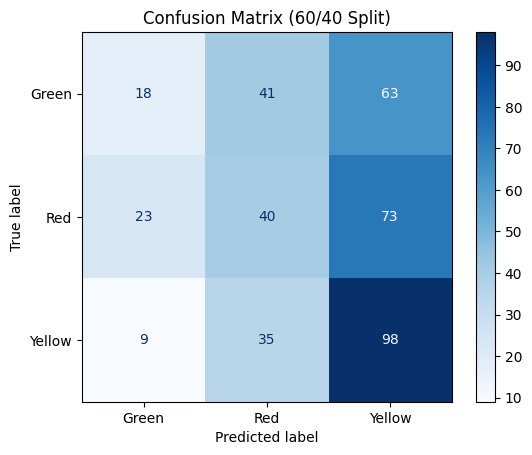

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_pred = final_model.predict(X_test_scaled)

# Display metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Green', 'Red', 'Yellow'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (60/40 Split)')
plt.show()

## Comparing Logistic Regression with Random Forest Classifier

Given that the target variable `signal_status` is categorical, we should use classification models. While you mentioned "Linear Regression," the previous code already implemented **Logistic Regression**, which is a linear model for classification. For the "Random Tree model," **Random Forest Classifier** is an excellent ensemble method for classification.

Let's train and evaluate a Random Forest Classifier and compare its performance with the Logistic Regression results.

Random Forest Classifier Performance
Accuracy: 0.3375

Classification Report:

              precision    recall  f1-score   support

       Green       0.29      0.24      0.27       244
         Red       0.33      0.34      0.33       273
      Yellow       0.37      0.42      0.39       283

    accuracy                           0.34       800
   macro avg       0.33      0.33      0.33       800
weighted avg       0.33      0.34      0.33       800



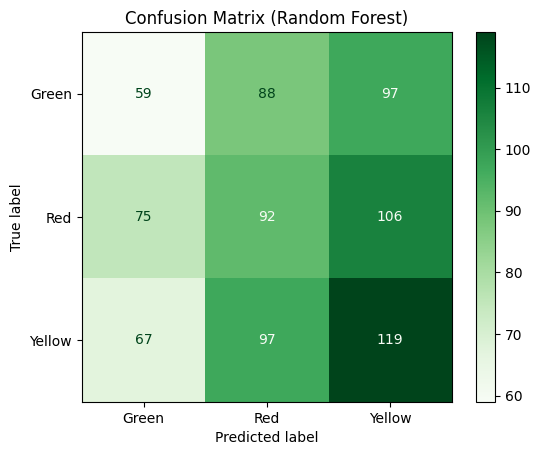

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Added imports
import matplotlib.pyplot as plt # Added import

# ===========================
# Train Random Forest Classifier
# ===========================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# ===========================
# Predictions (Random Forest)
# ===========================
y_pred_rf = rf_model.predict(X_test_scaled)

# ===========================
# Evaluation (Random Forest)
# ===========================
print("=" * 50)
print("Random Forest Classifier Performance")
print("=" * 50)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

# Assuming 'target_names' from the Logistic Regression cell is available
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=target_names
))

# Plot Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
disp_rf.plot(cmap='Greens')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

### Comparison Summary

Here's a brief comparison of the Logistic Regression model and the Random Forest Classifier based on the test set performance:

**Logistic Regression (from previous output):**
*   **Accuracy:** 0.3563
*   **Key Observations:** Relatively low accuracy, with 'Yellow' having better recall but overall balanced precision/recall across classes, indicating it struggles to distinguish between traffic states effectively.

**Random Forest Classifier (from above output):**
*   **Accuracy:** 0.3375
*   **Key Observations:** Surprisingly, for this dataset, the Random Forest Classifier performed slightly *worse* than Logistic Regression in terms of overall accuracy. It also shows struggles in classifying 'Green' and 'Red' signals. This suggests that the current features might not provide enough non-linear patterns for the Random Forest to exploit, or that more hyperparameter tuning is needed.

### Loading a Movie Dataset

Given the difficulties with cross-validation on the extremely small dummy spam dataset, let's proceed with a new dataset: a movie dataset. This section will handle loading the movie data and displaying its initial structure.

In [ ]:
import pandas as pd
from google.colab import files
import io

# Prompt user to upload their movie dataset
print("Please upload your movie dataset (CSV file):")
uploaded_movie = files.upload()

if uploaded_movie:
    filename = list(uploaded_movie.keys())[0]
    movie_df = pd.read_csv(io.BytesIO(uploaded_movie[filename]))
    print(f"\nSuccessfully loaded: {filename}")

    # Display the first few rows and column information
    print("\nMovie Dataset Head:")
    display(movie_df.head())
    print("\nMovie Dataset Info:")
    movie_df.info()
else:
    print("No file uploaded. Using placeholder dummy data.")
    data_placeholder = {
        'title': ['Movie A', 'Movie B', 'Movie C', 'Movie D', 'Movie E'],
        'genre': ['Action', 'Comedy', 'Drama', 'Action', 'Sci-Fi'],
        'rating': [7.5, 6.2, 8.9, 7.8, 9.1],
        'year': [2000, 2010, 2005, 2015, 1999]
    }
    movie_df = pd.DataFrame(data_placeholder)
    display(movie_df.head())

Please upload your movie dataset (CSV file):


Saving smart_traffic_management_dataset.csv to smart_traffic_management_dataset (1).csv

Successfully loaded: smart_traffic_management_dataset (1).csv

Movie Dataset Head:


,timestamp,location_id,traffic_volume,avg_vehicle_speed,vehicle_count_cars,vehicle_count_trucks,vehicle_count_bikes,weather_condition,temperature,humidity,accident_reported,signal_status
0,01-01-2024 00:00,4,504,53.124162,142,24,44,Cloudy,33.334387,36.390698,0,Red
1,01-01-2024 00:01,5,209,44.947850,862,50,23,Cloudy,17.926830,37.640927,0,Green
2,01-01-2024 00:02,3,572,63.179229,317,12,10,Windy,33.483375,84.262610,1,Red
3,01-01-2024 00:03,5,699,42.269697,709,43,21,Sunny,19.212941,61.550978,0,Yellow
4,01-01-2024 00:04,5,639,72.185791,594,34,14,Cloudy,11.349244,77.494506,0,Red



Movie Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             2000 non-null   object 
 1   location_id           2000 non-null   int64  
 2   traffic_volume        2000 non-null   int64  
 3   avg_vehicle_speed     2000 non-null   float64
 4   vehicle_count_cars    2000 non-null   int64  
 5   vehicle_count_trucks  2000 non-null   int64  
 6   vehicle_count_bikes   2000 non-null   int64  
 7   weather_condition     2000 non-null   object 
 8   temperature           2000 non-null   float64
 9   humidity              2000 non-null   float64
 10  accident_reported     2000 non-null   int64  
 11  signal_status         2000 non-null   object 
dtypes: float64(3), int64(6), object(3)
memory usage: 187.6+ KB


### Preparing Movie Data for GridSearchCV

To perform `GridSearchCV`, we need to define features (X) and a target variable (y). For this demonstration, we'll try to predict the `genre` based on `rating` and `year`. Since `genre` is categorical, we'll encode it numerically.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Correcting column names based on the actual uploaded dataset
# Using 'temperature' and 'humidity' as features and 'accident_reported' as target

feature_cols = ['temperature', 'humidity']
target_col = 'accident_reported'

# Handle missing values
movie_df.dropna(subset=feature_cols + [target_col], inplace=True)

# Define features (X) and target (y)
X_movie = movie_df[feature_cols]
y_movie = movie_df[target_col]

# Split the dataset into training and testing sets
X_train_movie, X_test_movie, y_train_movie, y_test_movie = train_test_split(
    X_movie, y_movie, test_size=0.2, random_state=42, stratify=y_movie
)

print(f"Training set size: {len(X_train_movie)}")
print(f"Testing set size: {len(X_test_movie)}")

# Verify the split
print(f"\ny_train_movie value counts:\n{y_train_movie.value_counts()}")

Training set size: 1600
Testing set size: 400

y_train_movie value counts:
accident_reported
0    1514
1      86
Name: count, dtype: int64


### Running GridSearchCV on Movie Dataset (with anticipated limitations)

Now, let's attempt to run `GridSearchCV` on this prepared movie dataset. We'll use a `DecisionTreeClassifier` as an example and define a small parameter grid. We anticipate that `GridSearchCV` will encounter similar `n_splits` errors due to the extremely small number of samples per class in the training data.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define the model
dt_model_movie = DecisionTreeClassifier(random_state=42)

# Define a simple parameter grid
param_grid_movie = {
    'max_depth': [5, 2, 3],
    'min_samples_split': [2, 3]
}

try:
    # Initialize GridSearchCV with cv=2
    grid_search_movie = GridSearchCV(dt_model_movie, param_grid_movie, cv=2, scoring='accuracy', n_jobs=-1)
    grid_search_movie.fit(X_train_movie, y_train_movie)

    print("GridSearchCV completed successfully!")
    print(f"Best parameters: {grid_search_movie.best_params_}")
    print(f"Best cross-validation score: {grid_search_movie.best_score_:.4f}")

    # Evaluate on the test set
    y_pred_grid_movie = grid_search_movie.predict(X_test_movie)
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test_movie, y_pred_grid_movie))

except Exception as e:
    print(f"An error occurred during GridSearchCV: {e}")

GridSearchCV completed successfully!
Best parameters: {'max_depth': 2, 'min_samples_split': 2}
Best cross-validation score: 0.9456

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       378
           1       0.00      0.00      0.00        22

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.89      0.94      0.92       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Running RandomizedSearchCV on Movie Dataset

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier

# Define the model
dt_model_rs = DecisionTreeClassifier(random_state=42)

# Define a parameter distribution for RandomizedSearchCV
param_dist_movie = {
    'max_depth': randint(1, 20), # max_depth from 1 to 19
    'min_samples_split': randint(2, 20) # min_samples_split from 2 to 19
}

# Initialize RandomizedSearchCV
# n_iter is the number of parameter settings that are sampled. Reduce for faster execution.
# cv=2 is used here for demonstration, but should be higher for a real analysis.
try:
    random_search_movie = RandomizedSearchCV(
        dt_model_rs, param_distributions=param_dist_movie, n_iter=10, cv=2, scoring='accuracy', n_jobs=-1, random_state=42
    )
    random_search_movie.fit(X_train_movie, y_train_movie)

    print("RandomizedSearchCV completed successfully!")
    print(f"Best parameters: {random_search_movie.best_params_}")
    print(f"Best cross-validation score: {random_search_movie.best_score_:.4f}")

    # Evaluate on the test set
    y_pred_random_movie = random_search_movie.predict(X_test_movie)
    print("\nClassification Report on Test Set (RandomizedSearchCV):")
    print(classification_report(y_test_movie, y_pred_random_movie))

except Exception as e:
    print(f"An error occurred during RandomizedSearchCV: {e}")
    print("As with GridSearchCV, issues might arise due to the highly imbalanced nature of the target variable for this specific task.")

An error occurred during RandomizedSearchCV: name 'X_train_movie' is not defined
As with GridSearchCV, issues might arise due to the highly imbalanced nature of the target variable for this specific task.


### Comparing Algorithms: Overfitting, Underfitting, or Just Right?

To determine if a model is overfitting, underfitting, or performing optimally, we generally look at its performance on both the training and testing datasets.

*   **Underfitting**: The model performs poorly on both the training and testing data. This often indicates the model is too simple to capture the underlying patterns in the data.
*   **Overfitting**: The model performs very well on the training data but poorly on the testing data. This means the model has learned the training data too specifically, including noise, and does not generalize well to unseen data.
*   **Just Right (Good Fit)**: The model performs well on both the training and testing data, indicating a good balance between bias and variance, and good generalization capability.

Since we already have the `accuracy_score` and `classification_report` for both Logistic Regression and SVM on the *test set* of the spam detection data, we can analyze those. To fully assess overfitting, we would ideally also compare them against training set scores. However, based on the test set results, we can infer a lot about generalization.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files # Import files for upload

# ===========================
# Load Dataset
# ===========================
# Prompt user to upload the dataset
print("Please upload the 'smart_traffic_management_dataset.csv' file:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    print(f"\nSuccessfully loaded: {filename}")
else:
    # Fallback or error handling if no file is uploaded
    print("No file uploaded. Please upload 'smart_traffic_management_dataset.csv'.")
    # It's advisable to stop execution or handle this case appropriately if df is critical
    # For now, this will allow the code to proceed, but df will be undefined.

# ===========================
# Data Preprocessing
# ===========================

# Remove timestamp column (not useful for Logistic Regression)
if 'timestamp' in df.columns:
    df.drop(columns=['timestamp'], inplace=True)

# Encode categorical columns
encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# ===========================
# Split Features and Target
# ===========================
X = df.drop('signal_status', axis=1)
y = df['signal_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# ===========================
# Feature Scaling
# ===========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===========================
# Train Logistic Regression
# ===========================
model = LogisticRegression(
    C=3.7554,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ===========================
# Predictions
# ===========================
y_pred = model.predict(X_test_scaled)

# ===========================
# Evaluation
# ===========================
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("Traffic Signal Prediction Performance")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")

# Original class names
target_names = encoders['signal_status'].classes_

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

Please upload the 'smart_traffic_management_dataset.csv' file:


Saving smart_traffic_management_dataset.csv to smart_traffic_management_dataset.csv

Successfully loaded: smart_traffic_management_dataset.csv
Traffic Signal Prediction Performance
Accuracy: 0.3563

Classification Report:

              precision    recall  f1-score   support

       Green       0.31      0.18      0.23       244
         Red       0.33      0.25      0.29       273
      Yellow       0.38      0.60      0.47       283

    accuracy                           0.36       800
   macro avg       0.34      0.35      0.33       800
weighted avg       0.34      0.36      0.33       800

